In [1]:
import alphapepttools as apt
import matplotlib as mpl
import matplotlib.pyplot as plt
import mudata as md
import muon
import numpy as np
import pandas as pd
import seaborn as sns

/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/site-packages/umap/__init__.py:9: ImportWarning: Tensorflow not installed; ParametricUMAP will be unavailable
  warn(
/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [2]:
# Mirror the central alphapepttools plot settings (defaults.PlotSettings) onto matplotlib's
# global rcParams so notebook figures match the library defaults.
from alphapepttools.pl import defaults

_plot_config = defaults.plot_settings.to_dict()
plt.rcParams.update(
    {
        "font.size": _plot_config["font_sizes"]["medium"],
        "axes.titlesize": _plot_config["axes"]["title_size"],
        "axes.labelsize": _plot_config["axes"]["label_size"],
        "xtick.labelsize": _plot_config["axes"]["tick_size"],
        "ytick.labelsize": _plot_config["axes"]["tick_size"],
        "legend.fontsize": _plot_config["legend"]["font_size"],
        "legend.title_fontsize": _plot_config["legend"]["title_size"],
        "lines.linewidth": _plot_config["linewidths"]["medium"],
        "lines.markersize": _plot_config["marker_sizes"]["medium"],
        "figure.dpi": _plot_config["resolution"]["dpi"],
        "savefig.dpi": _plot_config["resolution"]["dpi"],
        "svg.fonttype": "none",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

In [3]:
mdata = md.read_h5mu("../data/pp/lehtio2021_nsclc_multimodal.h5mu")

/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/site-packages/mudata/_core/mudata.py:571: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.
  self._update_attr_legacy(attr, axis, join_common, **kwargs)
/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/sit

In [4]:
total_explained_variance = pd.DataFrame(mdata.uns["mofa"]["variance"]).sum(axis=1)

## Factor activity

In [ ]:
list(sns.color_palette("Accent").as_hex())

palette = ["#6CC196", "#beaed4", "#fdc086", "#555555", "#386cb0"]

In [6]:
DIM_X, DIM_Y = 0, 2

VAR_X = total_explained_variance.loc[DIM_X]
VAR_Y = total_explained_variance.loc[DIM_Y]

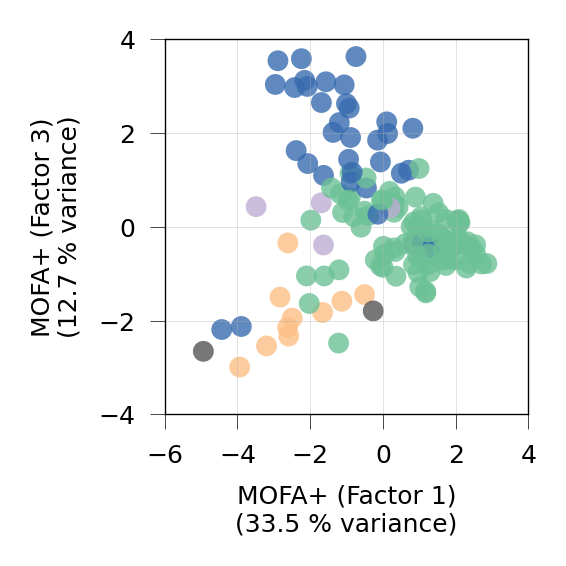

In [ ]:
# Keep only the spine/axis styling that defaults.PlotSettings does not govern;
# font sizes and weights now follow the global rcParams derived from defaults.
plot_params = {
    "axes.linewidth": 1.0,
}

with mpl.rc_context(plot_params):
    fig, ax = apt.pl.create_figure(1, 1, figsize=("0.5", "0.5"))
    muon.pl.embedding(
        mdata,
        basis="X_mofa",
        dimensions=(DIM_X, DIM_Y),
        ax=ax[0],
        show=False,
        alpha=0.8,
        size=100,
        color="who2015_histology",
        title="",
        palette=palette,
        zorder=1,
    )
    xmin, xmax = ax[0].get_xlim()
    ymin, ymax = ax[0].get_ylim()

    ax[0].set_xticks(np.arange(np.floor(xmin), xmax + 1, 2))
    ax[0].set_yticks(np.arange(np.floor(ymin), ymax + 1, 2))
    ax[0].grid(visible=True, which="major", alpha=0.5, zorder=-np.inf)

    legend = ax[0].legend()
    handles, labels = ax[0].get_legend_handles_labels()
    legend.remove()

    ax[0].set_xlabel(f"MOFA+ (Factor {DIM_X + 1})\n({VAR_X:.1f} % variance)")
    ax[0].set_ylabel(f"MOFA+ (Factor {DIM_Y + 1})\n({VAR_Y:.1f} % variance)")

fig.savefig("../data/plots/mofa-embedding.png", bbox_inches="tight", transparent=True)
plt.show()

/var/folders/py/838_q5nd6594y27wbrpkhl3h0000gn/T/ipykernel_13073/4205982035.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


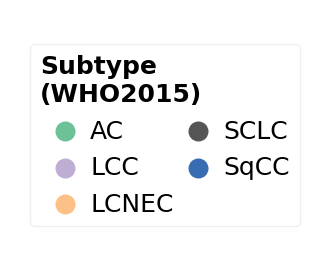

In [ ]:
for handle in handles:
    handle.set_sizes([20])

fontsize = 6


fig, axm = apt.pl.create_figure(1, 1, figsize=("0.25", "0.25"))
ax = axm.next()

ax.legend(
    handles,
    labels,
    loc="center",
    title="Subtype\n(WHO2015)",
    title_fontproperties={"weight": "bold", "size": fontsize},
    alignment="left",
    fontsize=fontsize,
    facecolor="#ffffff",
    framealpha=0.3,
    # edgecolor=",
    ncols=2,
    columnspacing=0.0,
    frameon=True,
    handletextpad=0.0,
)
ax.set_axis_off()
plt.tight_layout()
fig.savefig(
    "../data/plots/mofa-embedding.legend.png",
    bbox_inches="tight",
    dpi=600,
    transparent=True,
)
plt.show()

## Statistical significance

In [43]:
from scipy.stats import f_oneway, tukey_hsd, false_discovery_control

In [15]:
mofa_factors = mdata.obs.merge(
    pd.DataFrame(mdata.obsm["X_mofa"], index=mdata.obs_names),
    left_index=True,
    right_index=True,
)

mofa_factors

,proteins:tmt_sample_id,proteins:proteome_subtype,proteins:age,proteins:sex,proteins:previous_histology,proteins:who2015_histology,proteins:ac_mrna_subtype_tcga,proteins:sqcc_mrna_subtype_tcga,proteins:nsclc_mrna_subtype_karlsson_et_al._2017,proteins:smokingstatus,...,15,16,17,18,19,20,21,22,23,24
LU1155,set01_tmt10plex_126,6,76.334018,F,SqCC,SqCC,NaN,NaN,NaN,Former,...,-0.023227,-0.310810,0.230856,-0.197201,0.270907,0.140772,-0.458963,-0.241768,0.238488,1.478942
LU775,set01_tmt10plex_127N,6,75.000000,M,SqCC,SqCC,NaN,Classical,2.0,Former,...,-0.079507,-0.035133,-0.002586,0.011051,0.290966,0.291103,-0.122249,0.170698,0.459209,-6.328346
LU87,set01_tmt10plex_127C,3,70.000000,F,AC,AC,Terminal respiratory unit,NaN,6.0,Never_smoker,...,-0.543740,0.073733,-0.280438,-0.010827,0.180068,0.205086,0.248830,-0.253955,0.121122,0.016272
LU1132,set01_tmt10plex_128N,3,49.845311,F,AC,AC,NaN,NaN,NaN,Former,...,1.221986,0.237647,0.253736,0.008360,-0.001315,0.065789,-0.104567,0.116559,-0.209758,-1.016913
LU876,set01_tmt10plex_128C,3,44.000000,M,AC,AC,Terminal respiratory unit,NaN,9.0,Current,...,0.739680,-0.077035,0.314964,0.001170,0.000617,-0.027385,0.003837,-0.154460,-0.389352,0.201270
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LU820,set16_tmt10plex_128N,3,74.300000,M,LCC,SqCC,NaN,Secretory,4.0,Current,...,0.793426,0.334049,0.097174,0.127733,-0.033109,0.303669,0.002342,0.318109,-0.241014,0.001063
LU1124,set16_tmt10plex_129N,6,84.000000,F,SqCC,SqCC,NaN,Basal,2.0,Never_smoker,...,0.391940,-0.003066,0.067771,0.073045,-0.075678,-0.121779,-0.001443,-0.128480,0.000077,0.166548
LU1166,set16_tmt10plex_129C,6,77.817933,M,SqCC,SqCC,NaN,NaN,NaN,Current,...,-0.452673,-0.447956,-0.072639,0.005857,0.078348,-0.008889,0.003750,0.519397,0.299092,0.916292
LU1126,set16_tmt10plex_130C,1,66.729637,M,AC,AC,NaN,NaN,NaN,Current,...,0.909111,-0.334513,-0.121661,0.000573,0.002384,0.701103,0.002545,0.089858,0.350076,0.496239


### ANOVA

Test for significant differentces between histological conditions across all factors (25) and correct for multiple testing via BH. 

In [96]:
anova_results = []

groups = mofa_factors.groupby("proteins:who2015_histology", observed=True)

for factor in range(25):
    res = f_oneway(*[groups.get_group(group)[factor].to_list() for group in groups.groups.keys()], equal_var=False, nan_policy="raise")

    anova_results.append(
        {"factor": factor, "statistic": res.statistic, "p_value": res.pvalue}
    )

anova_results = pd.DataFrame(anova_results)
anova_results["fdr"] = false_discovery_control(anova_results["p_value"], method="bh")
anova_results["neg_log10_fdr"] = -1*np.log10(anova_results["fdr"])

anova_results

,factor,statistic,p_value,fdr,neg_log10_fdr
0,0,22.866844,0.001223,0.010195,1.991629
1,1,1.270877,0.380634,0.632633,0.198848
2,2,25.335202,0.000755,0.009432,2.025375
3,3,11.480026,0.006721,0.028005,1.552769
4,4,7.340717,0.006431,0.028005,1.552769
5,5,1.745232,0.242000,0.504166,0.297427
6,6,7.499493,0.016381,0.051191,1.290804
7,7,1.323301,0.356668,0.632633,0.198848
8,8,3.031984,0.088516,0.245878,0.609280
9,9,5.760257,0.004294,0.026840,1.571218


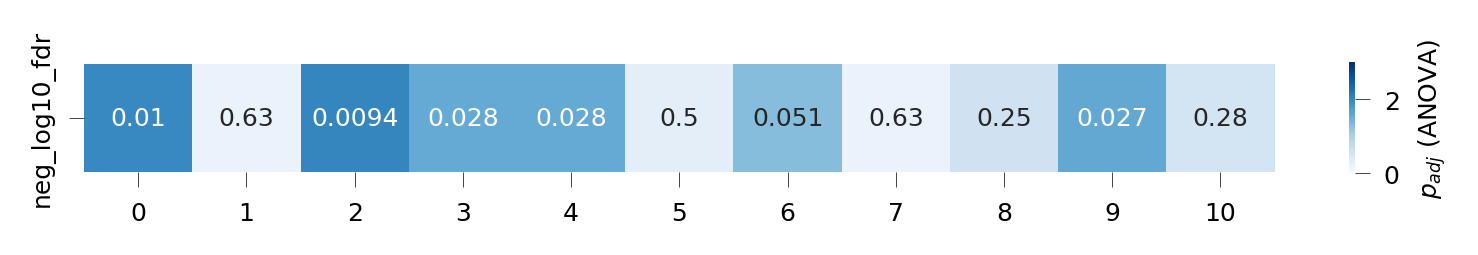

In [63]:
sns.heatmap(anova_results.loc[:10, ["neg_log10_fdr"]].T, square=True, vmin=0, vmax=3, cmap="Blues", annot=anova_results.loc[:10, ["fdr"]].T, fmt=".2g", cbar_kws={"shrink": 0.1, "label": "$p_{adj}$ (ANOVA)"})
plt.show()

/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


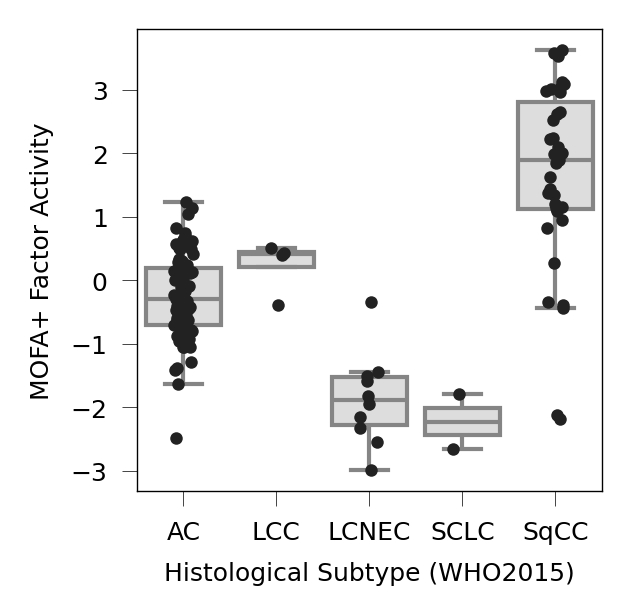

In [95]:
fig, ax = plt.subplots(1, 1, figsize=(2, 2))
sns.boxplot(mofa_factors, x="proteins:who2015_histology", y=2, fliersize=0, ax=ax, color="#dddddd")
sns.stripplot(mofa_factors, x="proteins:who2015_histology", y=2, ax=ax, color="#222222", size=3)
ax.set_ylabel("MOFA+ Factor Activity")
ax.set_xlabel("Histological Subtype (WHO2015)")

plt.show()

Test differences between groups for most significantly different factor with Tukey's HSD:

In [78]:
# most significant separation tested by ANOVA
factor = 2
res = tukey_hsd(*[groups.get_group(group)[factor].to_list() for group in groups.groups.keys()])
pd.DataFrame(res.pvalue, index=groups.groups.keys(), columns=groups.groups.keys())

,AC,LCC,LCNEC,SCLC,SqCC
AC,1.000000,0.842793,0.000005,2.625933e-02,0.000000e+00
LCC,0.842793,1.000000,0.001647,2.069232e-02,3.345796e-02
LCNEC,0.000005,0.001647,1.000000,9.871003e-01,0.000000e+00
SCLC,0.026259,0.020692,0.987100,1.000000e+00,4.704360e-07
SqCC,0.000000,0.033458,0.000000,4.704360e-07,1.000000e+00
